# Business Problem

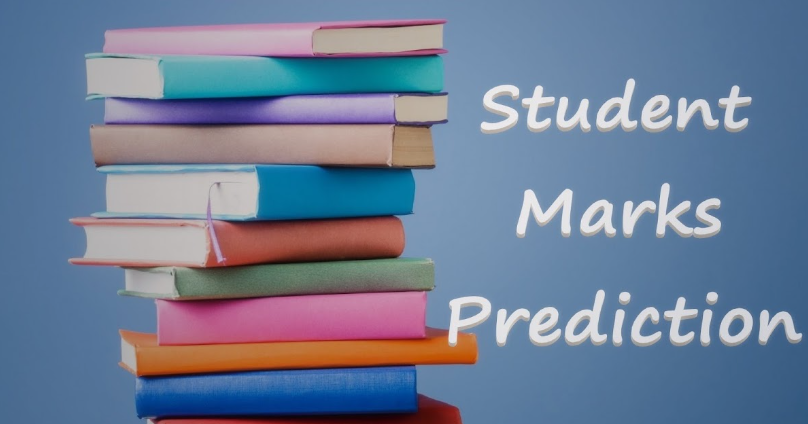

In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

# Load Dataset

In [2]:
marks = pd.read_csv(r"C:\Users\kunal\Downloads\student_info.csv")

In [3]:
marks


,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


# Discover and Visualize the Data to Gain Insights (EDA)
- **Objective**
  
Exploratory Data Analysis (EDA) is the process of exploring, summarizing, and visualizing the dataset to understand its characteristics, identify patterns, detect missing values or outliers, and gain insights before building a Machine Learning model.

# 1. Display the First Few Records

In [4]:
 
marks.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


- Displays the first 5 rows.
- Helps understand the dataset structure.
- Verifies whether the dataset loaded correctly.

# 2. Display the Last Few Records

In [5]:
marks.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


- Displays the last 5 rows.
 - Confirms that the dataset was completely loaded.

# 3. Check Dataset Shape

In [6]:
marks.shape

(200, 2)

- **200 Rows** → 200 students
- **2 Columns** → Study Hours and Student Marks

# 4. Display Column Names

In [7]:
marks.columns

Index(['study_hours', 'student_marks'], dtype='object')

- Shows all column names.
- Helps identify input and target variables.

# 5.Dataset Information summary

In [8]:
marks.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


The `info()` function provides a summary of the dataset, including the number of rows, columns, data types, non-null values, and memory usage.

### Key Insights
- Total records: **200**
- Total columns: **2**
- `study_hours` has **195 non-null values** (5 missing values).
- `student_marks` has **200 non-null values** (no missing values).
- Both columns have the **float64** data type.
- Memory usage is approximately **3.3 KB**.

## 6 . Descriptive statistics
#### Statistical Summary

In [9]:
marks.describe() 

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


In [10]:
marks.describe().T

,count,mean,std,min,25%,50%,75%,max
study_hours,195.0,6.995949,1.25306,5.01,5.775,7.12,8.085,8.99
student_marks,200.0,77.933750,4.92570,68.57,73.385,77.71,82.320,86.99


**The `describe()` function provides a summary of the numerical data in the dataset.**

#### Explanation

- **Count** – Number of non-missing values.
- **Mean** – Average value of the column.
- **Std** – Standard deviation, showing how much the values vary from the average.
- **Min** – Smallest value in the column.
- **25%** – 25% of the values are below this value.
- **50% (Median)** – Middle value of the dataset.
- **75%** – 75% of the values are below this value.
- **Max** – Largest value in the column.

#### Key Insights

- The average study time is **7 hours**.
- The average student marks are **77.93**.
- The `study_hours` column contains **5 missing values**.
- Study hours range from **5.01 to 8.99 hours**.
- Student marks range from **68.57 to 86.99**.

## 7. Check Missing Values

In [11]:
marks.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

**Missing Values using Heatmap**

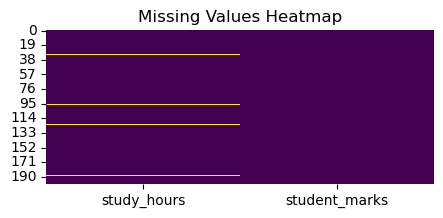

In [17]:
plt.figure(figsize=(5,2))

sns.heatmap(marks.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

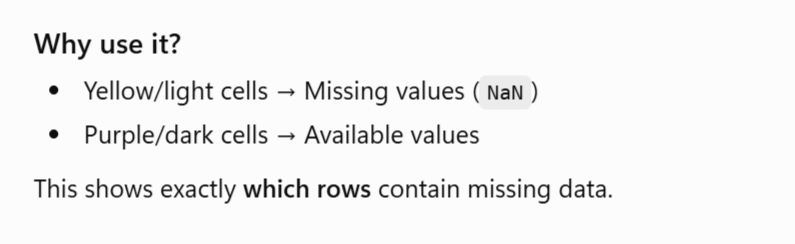

The heatmap visualizes the location of missing values in the dataset.

**Purpose**
- Detects missing values visually.
- Identifies which rows and columns contain `NaN`.
- Helps decide the appropriate missing value treatment.

**Missing Values Percentage**

In [18]:
missing_percent = marks.isnull().mean()*100
print(missing_percent)

study_hours      2.5
student_marks    0.0
dtype: float64


**not missing value percentage**

In [19]:
no_missing_percent = marks.notnull().mean()*100
print(no_missing_percent)

study_hours       97.5
student_marks    100.0
dtype: float64


# 8. Handle Missing Values

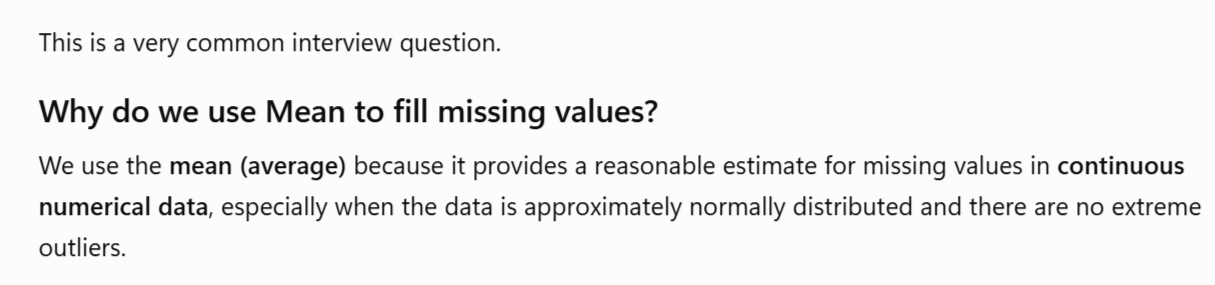
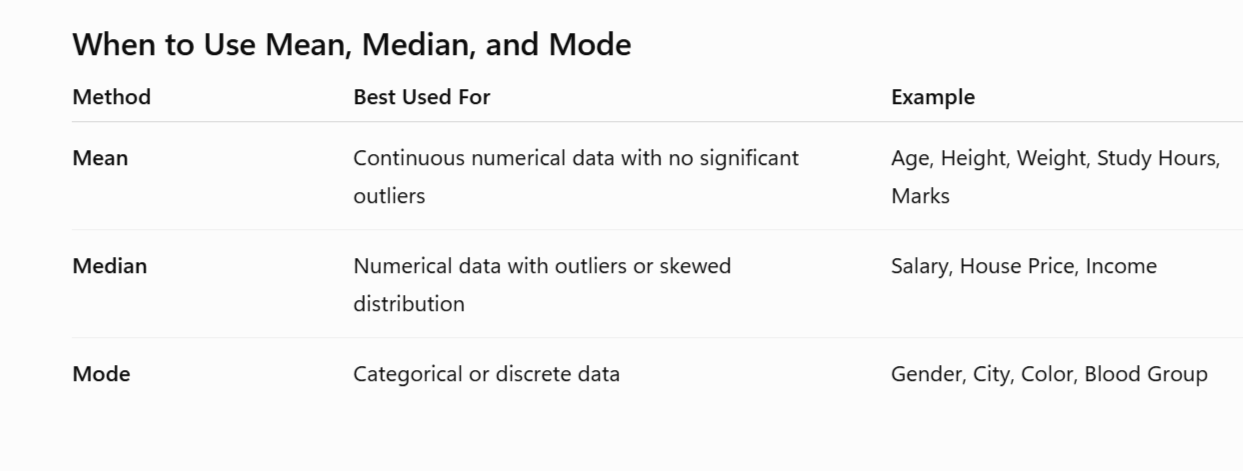

#### Histogram (Most Common)

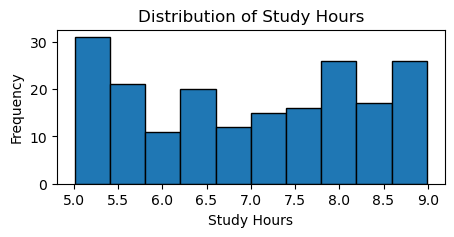

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,2))

plt.hist(marks["study_hours"], bins=10, edgecolor="black")

plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")

plt.show()

##### Distribution Plot (Histogram + KDE)

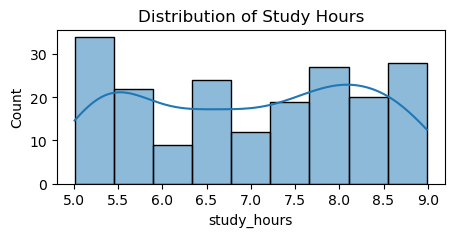

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,2))

sns.histplot(marks["study_hours"], kde=True)

plt.title("Distribution of Study Hours")

plt.show()

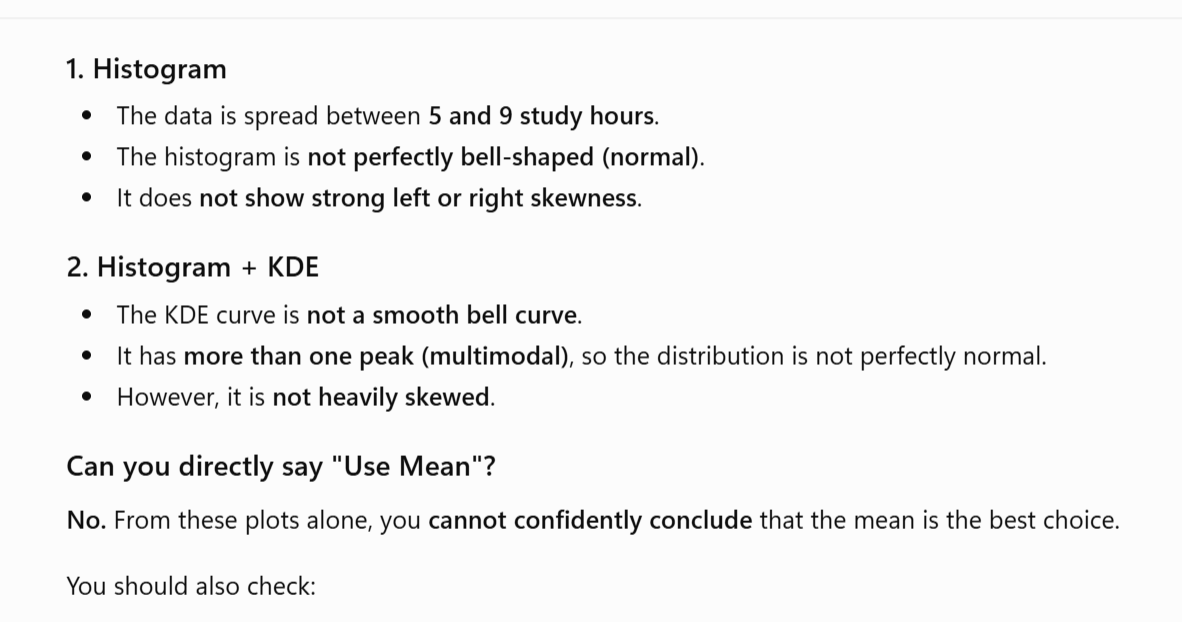

In [22]:
# Check skewness
print(marks["study_hours"].skew())



-0.06131042179501742


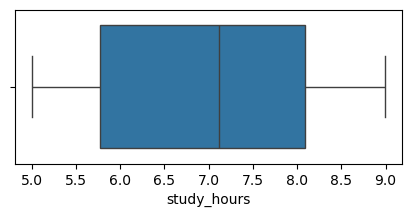

In [23]:
# Check outliers
plt.figure(figsize=(5,2))
sns.boxplot(x=marks["study_hours"])
plt.show()

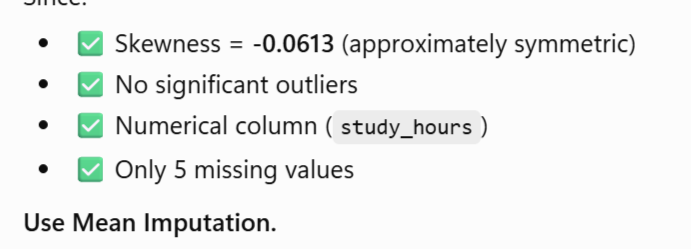

### Use mean to fill missing handling

In [24]:
marks.mean()

study_hours       6.995949
student_marks    77.933750
dtype: float64

In [28]:
# Data Cleaning
marks2 = marks.fillna(marks.mean())

In [29]:
#If your dataset has only one missing numerical column (study_hours), an even better approach is:
# marks2["study_hours"] = marks["study_hours"].fillna(marks["study_hours"].mean())

In [30]:
## Verify Missing Values
marks2.isnull().sum()

study_hours      0
student_marks    0
dtype: int64



The `isnull().sum()` function is used to check the number of missing values in each column after data preprocessing.

### Observation

- `study_hours` contains **0 missing values**.
- `student_marks` contains **0 missing values**.

### Conclusion

**All missing values have been successfully handled, and the dataset is now complete and ready for further preprocessing and machine learning model training.**

# 9.Prepare the data for Machine Learning algorithms 

In [31]:
marks # original dataset

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [32]:
marks2 # clean dataset

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


In [59]:
marks2.isnull().sum() 

study_hours      0
student_marks    0
dtype: int64

In [66]:
marks2.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


In [10]:
marks2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    200 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [12]:
marks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


# 10. Analyze Relationship
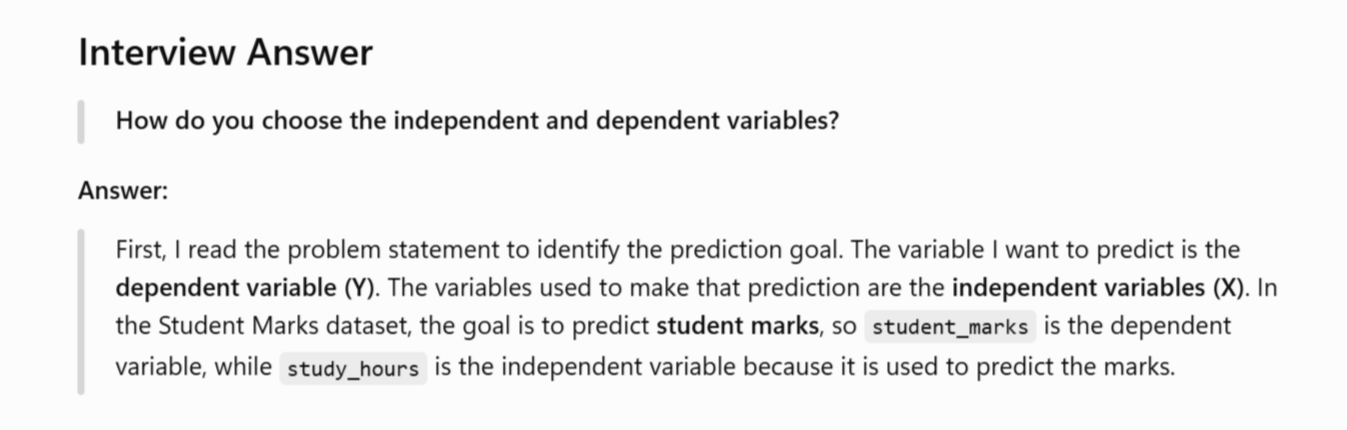

### Purpose
- Understand the relationship between input and output variables.
- Identify positive, negative, or no correlation.
- Detect trends and outliers.
- Select a suitable machine learning model.

##  Scatter Plot

- **A scatter plot is used to visualize the relationship between two numerical variables.** 
- **Each point represents one student's study hours and corresponding marks.**


### Purpose
- Identify the relationship between `study_hours` and `student_marks`.
- Check whether the relationship is positive, negative, or absent.
- Detect outliers.
- Determine whether Linear Regression is suitable.



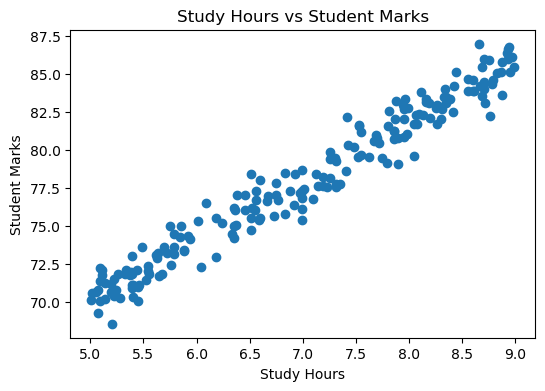

In [41]:
plt.figure(figsize=(6,4))

plt.scatter(marks2["study_hours"],
            marks2["student_marks"])

plt.title("Study Hours vs Student Marks")
plt.xlabel("Study Hours")
plt.ylabel("Student Marks")

plt.show()


### Observation
- If the points form an upward trend, it indicates a **positive relationship**, meaning students who study more generally score higher marks.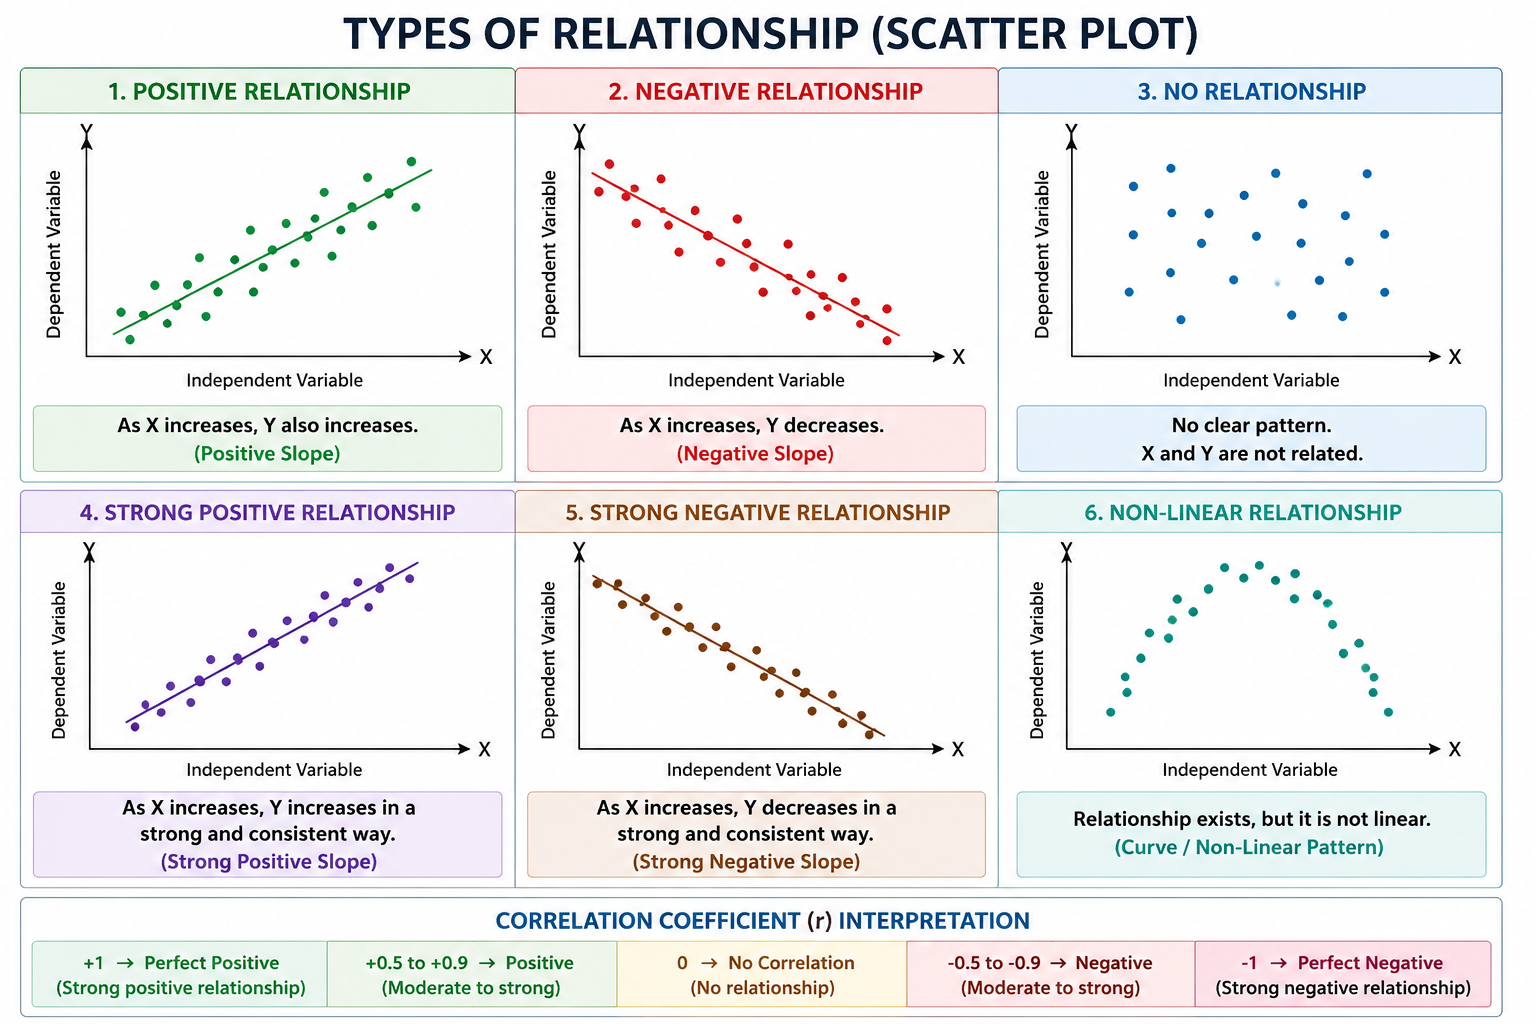!

# Correlation plot

#### - Correlation measures the strength and direction of the relationship between numerical variables. 
#### - The correlation coefficient ranges from **-1 to +1.**

In [42]:
marks2.corr()

,study_hours,student_marks
study_hours,1.000000,0.978696
student_marks,0.978696,1.000000


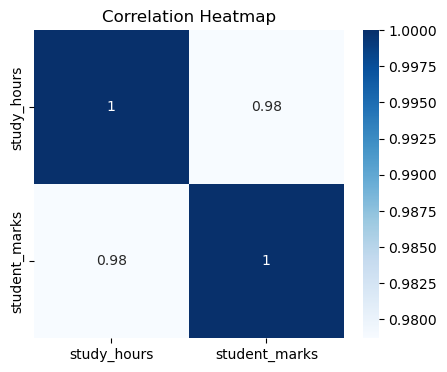

In [43]:
# correlation Heatmap
plt.figure(figsize=(5,4))

sns.heatmap(marks2.corr(),
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

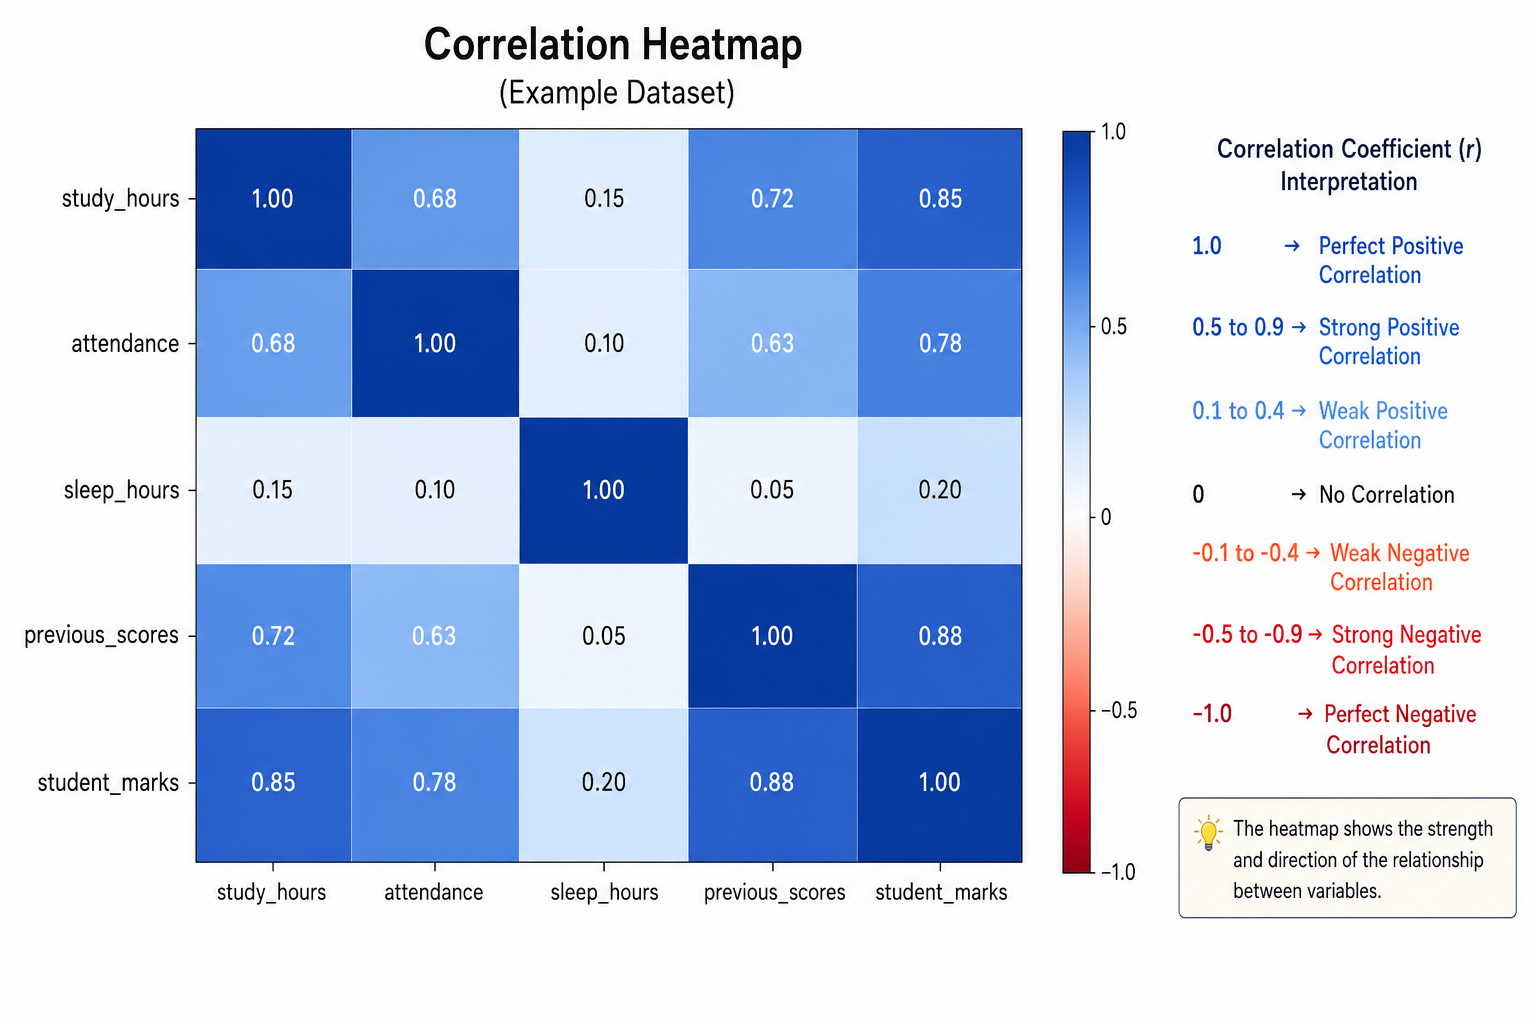!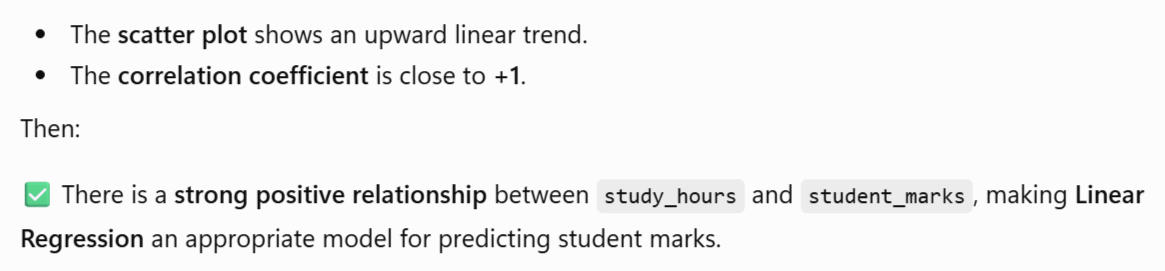

# 11. Separate Features (X) and Target (Y).(split dataset)

The dataset is divided into **input features (X)** and the **target variable (Y)**.

- **Features (X):** Independent variables used to make predictions.
- **Target (Y):** Dependent variable that the model learns to predict.

For this dataset:
- `study_hours` is the target(y).
- `student_marks` is the feature (x).## Separate Features and Target



In [38]:
# Separate the independent variable (Feature - X)
# Drop the target column 'student_marks'
X = marks2.drop("student_marks", axis="columns")

# Separate the dependent variable (Target - Y)
# Drop the feature column 'study_hours'
y = marks2.drop("study_hours", axis="columns")

# Display the shape of X and y
print("Shape of X =", X.shape)
print("Shape of y =", y.shape)

Shape of X = (200, 1)
Shape of y = (200, 1)


**OR**

In [39]:
X

,study_hours
0,6.830000
1,6.560000
2,6.995949
3,5.670000
4,8.670000
...,...
195,7.530000
196,8.560000
197,8.940000
198,6.600000


In [40]:
y

,student_marks
0,78.50
1,76.74
2,78.68
3,71.82
4,84.19
...,...
195,81.67
196,84.68
197,86.75
198,78.05


# 12. Train-Test Split
## Split the Dataset

The dataset is divided into **training** and **testing** sets.

- **Training Set:** Used to train the machine learning model.
- **Testing Set:** Used to evaluate the model's performance on unseen data.

A common split is **80% training** and **20% testing**.

In [44]:
# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% of the data is used for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=0
)

# Display the shape of the training and testing datasets
print("Shape of X_train =", X_train.shape)
print("Shape of y_train =", y_train.shape)
print("Shape of X_test  =", X_test.shape)
print("Shape of y_test  =", y_test.shape)

Shape of X_train = (160, 1)
Shape of y_train = (160, 1)
Shape of X_test  = (40, 1)
Shape of y_test  = (40, 1)


In [45]:
X_train

,study_hours
134,6.51
66,7.86
26,6.51
113,7.95
168,7.95
...,...
67,8.26
192,8.71
117,8.83
47,5.01


In [46]:
X_test.shape

(40, 1)

In [47]:
y_train

,student_marks
134,78.39
66,81.25
26,74.75
113,80.86
168,82.68
...,...
67,81.70
192,84.03
117,85.04
47,70.11


In [48]:
y_test

,student_marks
18,82.50
170,71.18
107,73.25
98,83.64
177,73.64
182,86.99
5,81.18
146,82.75
12,79.50
152,81.70


## Train-Test Split

The dataset is divided into **training** and **testing** sets using the `train_test_split()` function.

### Purpose

- **Training Set (`X_train`, `y_train`)**: Used to train the machine learning model.
- **Testing Set (`X_test`, `y_test`)**: Used to evaluate the model's performance on unseen data.

### Parameters

- **test_size = 0.2** → 20% of the data is used for testing, and 80% is used for training.
- **random_state = 0** → Ensures that the data is split in the same way every time the code is executed, making the results reproducible.

### Output

- **X_train** → Training feature data.
- **y_train** → Training target data.
- **X_test** → Testing feature data.
- **y_test** → Testing target data.

## Random State

The `random_state` parameter controls the randomness of the train-test split.

### Purpose

- Ensures the dataset is split in the same way every time the code is executed.
- Makes the experiment reproducible.
- Helps compare different machine learning models using the same training and testing data.

### Note

The values `0` and `42` are commonly used seed values. They do not affect the quality of the model; they only determine the random split of the dataset.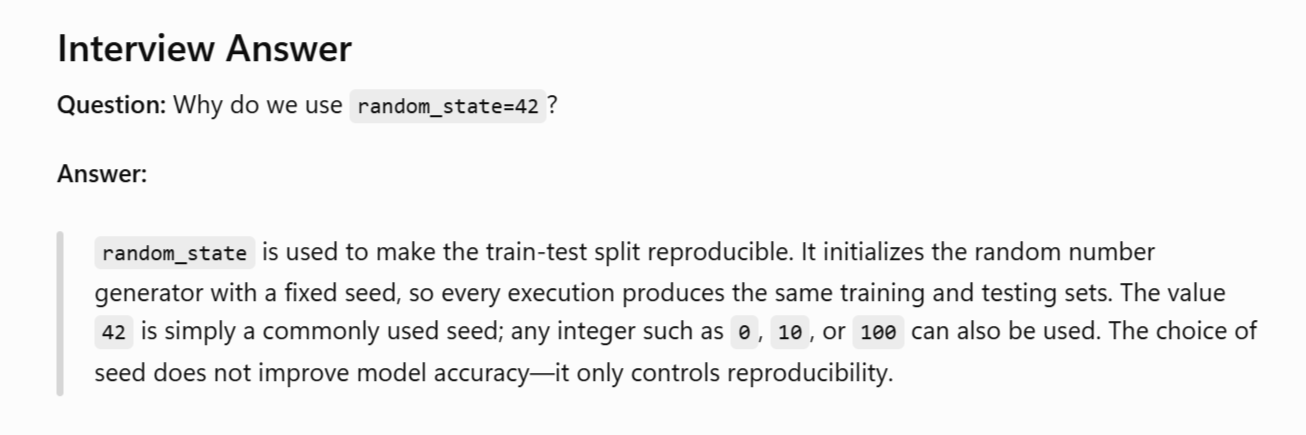

# 13. Select Model and Train the Linear Regression Model


The Linear Regression model is trained using the training dataset (`X_train` and `y_train`).

During training, the model learns the relationship between the input feature (`study_hours`) and the target variable (`student_marks`). It calculates the best-fit line that minimizes the prediction error.

### Purpose

- Learn the relationship between study hours and student marks.
- Estimate the best-fit regression line.
- Prepare the model for making predictions on new data.

In [51]:
# Linear Regression Equation:
# y = m * x + c

# Import the Linear Regression algorithm
from sklearn.linear_model import LinearRegression   #LinearRegression() is a class.


# Create an object (instance) of the Linear Regression model
lr = LinearRegression()
lr   # lr is an object (instance) of that class.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### y = m * x + c
Where:
- **y** = Predicted value (Student Marks)
- **m** = Slope (Coefficient)
- **x** = Independent variable (Study Hours)
- **c** = Intercept (Constant)


### What is fit()?

**fit()** is a method (function) inside the LinearRegression class.

It trains the model using the training data.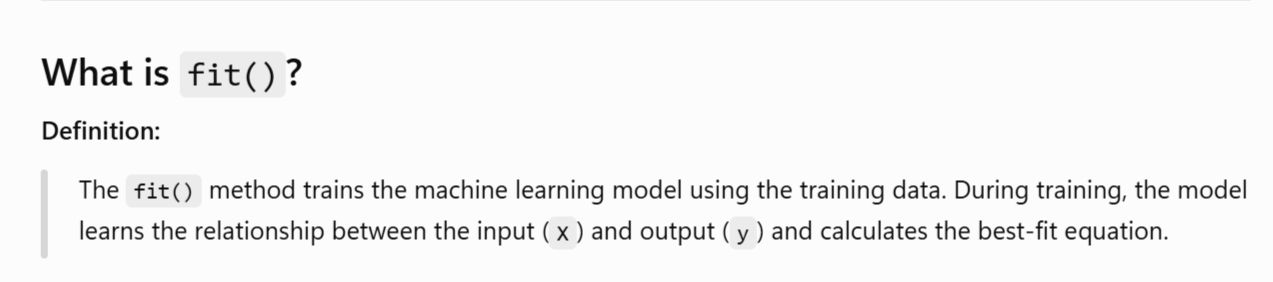

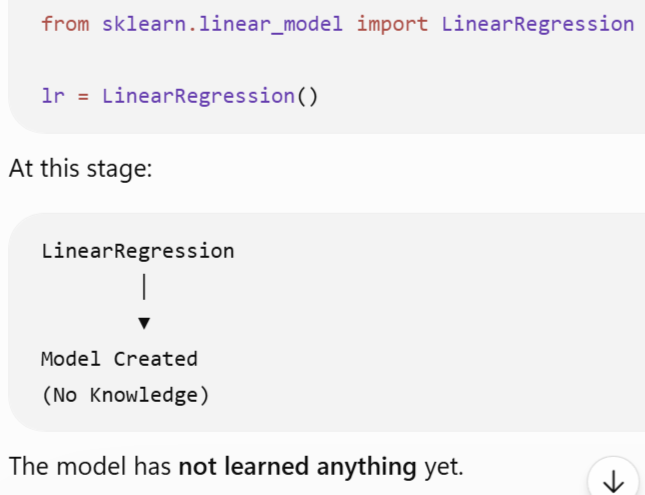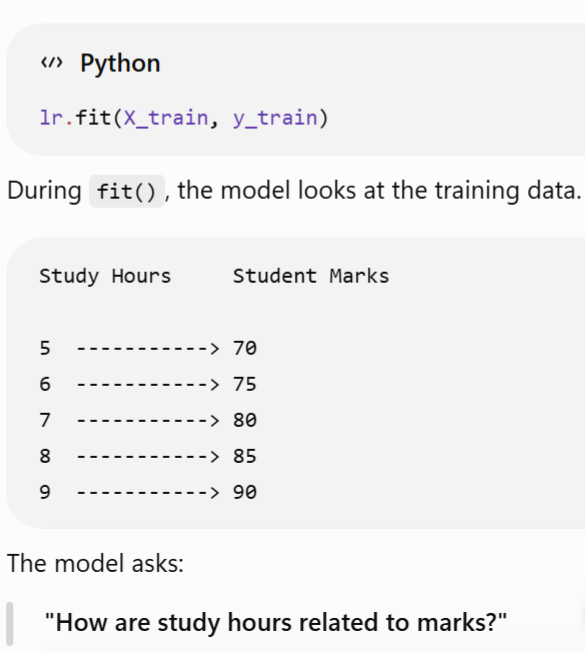

In [52]:
lr.fit(X_train,y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
lr.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

### Model Parameters

The `get_params()` method returns all the configuration parameters (hyperparameters) of the Linear Regression model.

### Purpose

- Display the model's parameter settings.
- Check the default values.
- Verify any custom parameters before training the model.

**Note:** `get_params()` shows only the model configuration. It does **not** display the learned coefficient or intercept.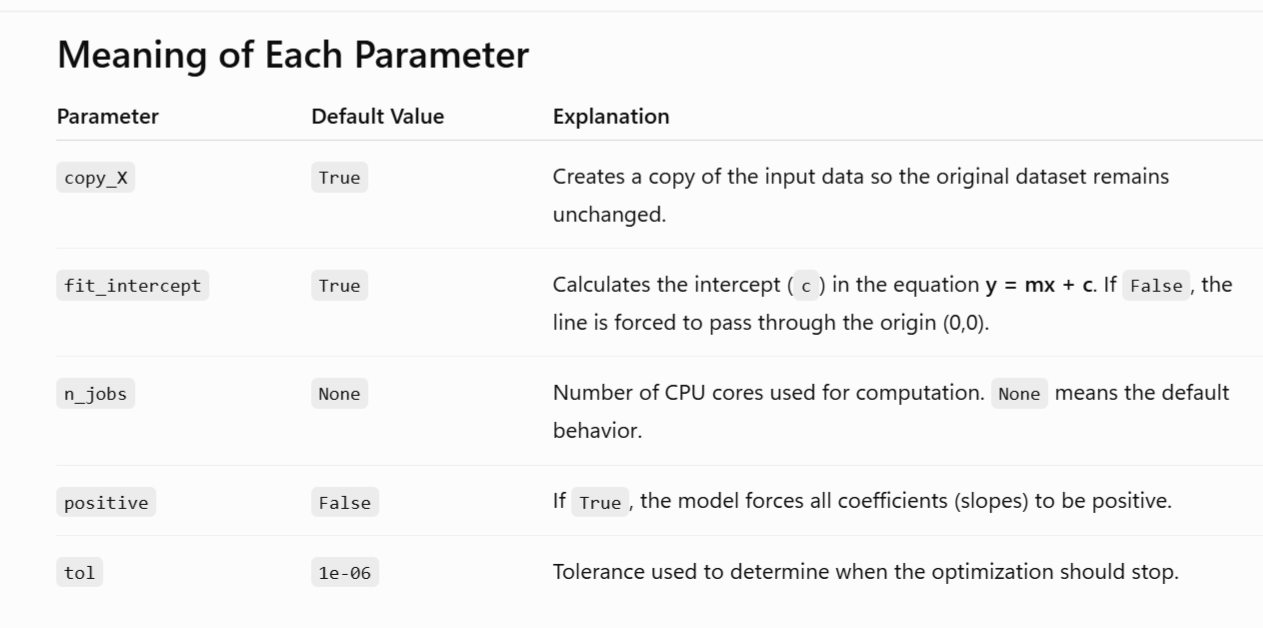

In [21]:
lr.coef_ #m

array([[3.93037294]])

In [22]:
lr.intercept_ #c

array([50.45063632])

In [25]:
m = 3.93
c = 50.44
y  = m * 10 + c 
y

89.74000000000001

In [35]:
m = 3.93
c = 50.44
y  = m * 11 + c 
y

93.67

In [26]:
lr.predict([[11]]).round(2)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[93.68]])

In [27]:
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
#lr.predict([[5]])[0][0].round(2)

In [28]:
y_pred  = lr.predict(X_test)
y_pred

array([[83.50507271],
       [70.84927186],
       [72.93236952],
       [85.35234799],
       [73.20749562],
       [84.48766595],
       [80.12495199],
       [81.85431608],
       [80.91102657],
       [82.20804964],
       [78.98514384],
       [84.84139951],
       [77.84533568],
       [77.68812077],
       [83.22994661],
       [85.78468901],
       [84.9593107 ],
       [72.61793968],
       [78.71001773],
       [79.18166248],
       [84.2911473 ],
       [85.6274741 ],
       [74.74034107],
       [81.3433676 ],
       [72.02838374],
       [80.40007809],
       [78.98514384],
       [82.09013845],
       [77.94732382],
       [82.24735337],
       [75.44780819],
       [84.60557713],
       [71.63534645],
       [75.48711192],
       [70.29901965],
       [78.98514384],
       [75.32989701],
       [84.52696967],
       [74.07217767],
       [71.4388278 ]])

In [29]:
pd.DataFrame(np.c_[X_test, y_test, y_pred], columns = ["study_hours", "student_marks_original","student_marks_predicted"])

,study_hours,student_marks_original,student_marks_predicted
0,8.410000,82.50,83.505073
1,5.190000,71.18,70.849272
2,5.720000,73.25,72.932370
3,8.880000,83.64,85.352348
4,5.790000,73.64,73.207496
5,8.660000,86.99,84.487666
6,7.550000,81.18,80.124952
7,7.990000,82.75,81.854316
8,7.750000,79.50,80.911027
9,8.080000,81.70,82.208050


## Fine-tune your model

In [30]:
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
lr.score(X_test,y_test) # variance

0.9521841793508594

In [32]:
lr.score(X_train,y_train) # bias

0.9584528455152638

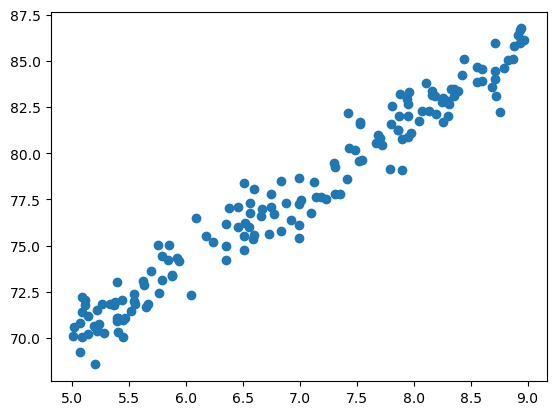

In [41]:
plt.scatter(X_train,y_train) 

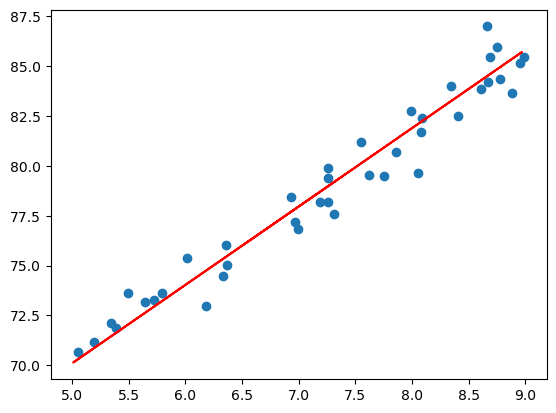

In [33]:
plt.scatter(X_test, y_test)
plt.plot(X_train, lr.predict(X_train), color = "r")

## Present your solution

## Save Ml Model

In [34]:
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
import joblib # create pipeline 
joblib.dump(lr, "Desktop.pkl")

['Desktop.pkl']

In [38]:
pwd

'C:\\Users\\Admin\\AnacondaCode\\DATASCIENCE_IMP PROJECTS'

In [39]:
model = joblib.load("Desktop.pkl")  # pickle 

In [40]:
pwd

'C:\\Users\\Admin\\AnacondaCode\\DATASCIENCE_IMP PROJECTS'

In [58]:
#lr.predict([[5]])[0][0].round(2)

# Launch, monitor, and maintain your system

In [1]:
__name__

'__main__'

# Student Marks Dataset

## Objective
The dataset is used to predict student marks based on study hours using Machine Learning Regression.

### Columns

1. **study_hours**
   - Independent Variable (X)
   - Represents the number of hours a student studies.
   - Data Type: Float

2. **student_marks**
   - Dependent Variable (Y)
   - Represents the marks scored by the student.
   - Data Type: Float

### Dataset Characteristics
- Total Columns: 2
- Input Feature: study_hours
- Target Feature: student_marks
- Data Type: Numerical
- Machine Learning Type: Supervised Learning
- Algorithm Type: Regression

### Missing Values
The `study_hours` column contains `NaN`, which represents missing data. These missing values should be handled before training the model.

### Goal
Build a regression model that predicts student marks based on study hours.